In [111]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_selection import (
  SelectFromModel
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [112]:
!pip install ucimlrepo

In [113]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151)

# data (as pandas dataframes)
X = connectionist_bench_sonar_mines_vs_rocks.data.features
y = connectionist_bench_sonar_mines_vs_rocks.data.targets

# metadata
print(connectionist_bench_sonar_mines_vs_rocks.metadata)

# variable information
print(connectionist_bench_sonar_mines_vs_rocks.variables)

{'uci_id': 151, 'name': 'Connectionist Bench (Sonar, Mines vs. Rocks)', 'repository_url': 'https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks', 'data_url': 'https://archive.ics.uci.edu/static/public/151/data.csv', 'abstract': 'The task is to train a network to discriminate between sonar signals bounced off a metal cylinder and those bounced off a roughly cylindrical rock.', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 208, 'num_features': 60, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': None, 'dataset_doi': '10.24432/C5T01Q', 'creators': ['Terry Sejnowski', 'R. Gorman'], 'intro_paper': None, 'additional_info': {'summary': 'The file "sonar.mines" contains 111 patterns obtained by bouncing sonar signals off a metal cylinder at various a

In [114]:
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094


In [115]:
y.head()

,class
0,R
1,R
2,R
3,R
4,R


In [116]:
X.isnull().sum()

,0
Attribute1,0
Attribute2,0
Attribute3,0
Attribute4,0
Attribute5,0
Attribute6,0
Attribute7,0
Attribute8,0
Attribute9,0
Attribute10,0


In [117]:
y.isnull().sum()

,0
class,0


In [118]:
X.duplicated().sum()

np.int64(0)

In [119]:
encoder=LabelEncoder()
y=encoder.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [120]:
encoder.classes_

array(['M', 'R'], dtype=object)

In [121]:
np.unique(y,return_counts=True)

(array([0, 1]), array([111,  97]))

In [122]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [123]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [124]:
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [125]:
lr_predictions=lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [126]:
baseline_accuracy=accuracy_score(y_test,lr_predictions)
baseline_precision=precision_score(y_test,lr_predictions)
baseline_recall=recall_score(y_test,lr_predictions)
baseline_f1_score=f1_score(y_test,lr_predictions)

print(f"Accuracy: {baseline_accuracy*100:.2f}%")
print(f"Precision: {baseline_precision:.2f}")
print(f"Recall: {baseline_recall:.2f}")
print(f"F1-Score: {baseline_f1_score:.2f}")

Accuracy: 52.38%
Precision: 0.00
Recall: 0.00
F1-Score: 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [127]:
baseline_model=RandomForestClassifier(n_estimators=200,random_state=42)

In [128]:
baseline_model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [129]:
baseline_predictions=baseline_model.predict(X_test)

In [130]:
baseline_accuracy=accuracy_score(y_test,baseline_predictions)
baseline_precision=precision_score(y_test,baseline_predictions)
baseline_recall=recall_score(y_test,baseline_predictions)
baseline_f1_score=f1_score(y_test,baseline_predictions)

print(f"backward Accuracy: {baseline_accuracy*100:.2f}%")
print(f"backward Precision: {baseline_precision:.2f}")
print(f"backward Recall: {baseline_recall:.2f}")
print(f"backward F1-Score: {baseline_f1_score:.2f}")

backward Accuracy: 85.71%
backward Precision: 1.00
backward Recall: 0.70
backward F1-Score: 0.82


In [131]:
X_train.shape[1]

60

In [132]:
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [133]:
dt_importance=pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
})

In [134]:
dt_importance.sort_values(by="Importance",ascending=False,inplace=True)

In [135]:
dt_importance.head(15)

,Feature,Importance
11,Attribute12,0.246293
20,Attribute21,0.133015
41,Attribute42,0.095076
50,Attribute51,0.092575
26,Attribute27,0.080400
46,Attribute47,0.068151
22,Attribute23,0.064277
52,Attribute53,0.039802
3,Attribute4,0.037185
34,Attribute35,0.030356


In [136]:
dt_importance[dt_importance['Importance']!=0]

,Feature,Importance
11,Attribute12,0.246293
20,Attribute21,0.133015
41,Attribute42,0.095076
50,Attribute51,0.092575
26,Attribute27,0.080400
46,Attribute47,0.068151
22,Attribute23,0.064277
52,Attribute53,0.039802
3,Attribute4,0.037185
34,Attribute35,0.030356


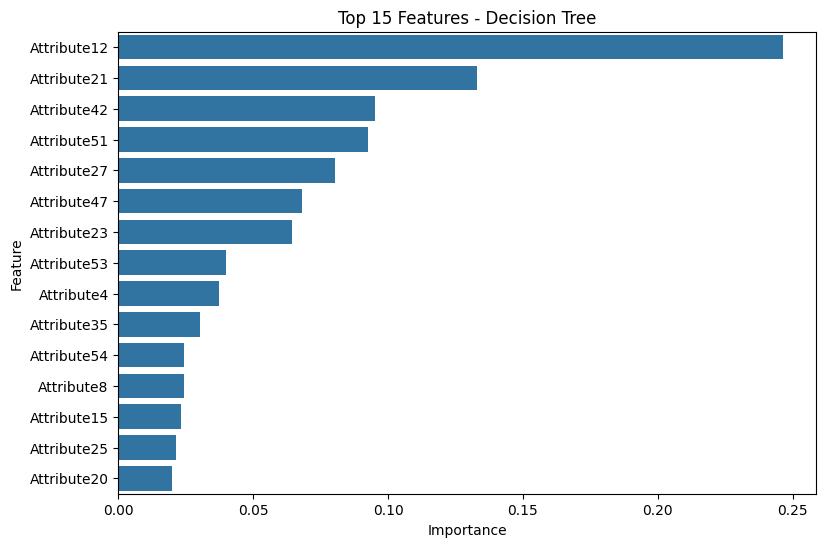

In [137]:
top_dt=dt_importance.head(15)
plt.figure(figsize=(9,6))
sns.barplot(data=top_dt,x="Importance",y='Feature')
plt.title("Top 15 Features - Decision Tree")
plt.show()

In [138]:
dt_selector=SelectFromModel(dt,threshold="mean",prefit=True)

In [139]:
dt_selected_features=X_train.columns[dt_selector.get_support()]

In [140]:
print(dt_selected_features)

Index(['Attribute4', 'Attribute8', 'Attribute12', 'Attribute15', 'Attribute20',
       'Attribute21', 'Attribute23', 'Attribute25', 'Attribute27',
       'Attribute35', 'Attribute42', 'Attribute47', 'Attribute51',
       'Attribute53', 'Attribute54'],
      dtype='object')


In [141]:
X_train_tree=dt_selector.transform(X_train)
X_test_tree=dt_selector.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [142]:
X_train_tree.shape

(166, 15)

In [143]:
rf_tree=RandomForestClassifier(n_estimators=200,random_state=42)

In [144]:
rf_tree.fit(X_train_tree,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [145]:
rf_tree_predictions=rf_tree.predict(X_test_tree)

In [146]:
rf_tree_accuracy=accuracy_score(y_test,rf_tree_predictions)
rf_tree_precision=precision_score(y_test,rf_tree_predictions)
rf_tree_recall=recall_score(y_test,rf_tree_predictions)
rf_tree_f1_score=f1_score(y_test,rf_tree_predictions)

print(f"Accuracy: {rf_tree_accuracy*100:.2f}%")
print(f"Precision: {rf_tree_precision:.2f}")
print(f"Recall: {rf_tree_recall:.2f}")
print(f"F1-Score: {rf_tree_f1_score:.2f}")

Accuracy: 69.05%
Precision: 0.82
Recall: 0.45
F1-Score: 0.58


In [147]:
scaler=StandardScaler()

In [148]:
X_train_lr=scaler.fit_transform(X_train_tree)
X_test_lr=scaler.transform(X_test_tree)

In [149]:
lr=LogisticRegression()
lr.fit(X_train_lr,y_train)

LogisticRegression()

In [150]:
lr_predictions=lr.predict(X_test_lr)

In [151]:
baseline_accuracy=accuracy_score(y_test,lr_predictions)
baseline_precision=precision_score(y_test,lr_predictions)
baseline_recall=recall_score(y_test,lr_predictions)
baseline_f1_score=f1_score(y_test,lr_predictions)

print(f"Accuracy: {baseline_accuracy*100:.2f}%")
print(f"Precision: {baseline_precision:.2f}")
print(f"Recall: {baseline_recall:.2f}")
print(f"F1-Score: {baseline_f1_score:.2f}")

Accuracy: 76.19%
Precision: 0.86
Recall: 0.60
F1-Score: 0.71


Apply embedded feature selection method using Decision Tree and build a logistic regression model using selected features on Ionosphere Dataset

In [152]:
!pip install ucimlrepo

In [153]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ionosphere = fetch_ucirepo(id=52)

# data (as pandas dataframes)
X = ionosphere.data.features
y = ionosphere.data.targets

# metadata
print(ionosphere.metadata)

# variable information
print(ionosphere.variables)


{'uci_id': 52, 'name': 'Ionosphere', 'repository_url': 'https://archive.ics.uci.edu/dataset/52/ionosphere', 'data_url': 'https://archive.ics.uci.edu/static/public/52/data.csv', 'abstract': 'Classification of radar returns from the ionosphere', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 351, 'num_features': 34, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Sun Jan 01 1989', 'dataset_doi': '10.24432/C5W01B', 'creators': ['V. Sigillito', 'S. Wing', 'L. Hutton', 'K. Baker'], 'intro_paper': None, 'additional_info': {'summary': 'This radar data was collected by a system in Goose Bay, Labrador.  This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts.  See the paper for more details.  

In [154]:
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,1.00000,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697


In [155]:
l1_model=LogisticRegression(penalty='l1',solver='liblinear',C=0.5,max_iter=5000,random_state=42)

In [156]:
l1_model.fit(X_train_scaled,y_train)

LogisticRegression(C=0.5, max_iter=5000, penalty='l1', random_state=42,
                   solver='liblinear')

In [157]:
l1_coeff=pd.DataFrame({
    "Feature":X_train.columns,
    "Coefficient":l1_model.coef_[0]
})

In [158]:
l1_coeff

,Feature,Coefficient
0,Attribute1,-0.239863
1,Attribute2,0.000000
2,Attribute3,0.213620
3,Attribute4,-0.488632
4,Attribute5,0.000000
5,Attribute6,0.000000
6,Attribute7,0.308247
7,Attribute8,0.256075
8,Attribute9,-0.323658
9,Attribute10,0.000000


In [159]:
l1_coeff['Absolute_Coefficient']=np.abs(l1_coeff['Coefficient'])

In [160]:
l1_coeff.sort_values("Absolute_Coefficient",ascending=False,inplace=True)

In [161]:
l1_coeff.head(20)

,Feature,Coefficient,Absolute_Coefficient
11,Attribute12,-0.548743,0.548743
3,Attribute4,-0.488632,0.488632
51,Attribute52,-0.445614,0.445614
35,Attribute36,0.403149,0.403149
21,Attribute22,-0.390759,0.390759
10,Attribute11,-0.388299,0.388299
48,Attribute49,-0.384876,0.384876
30,Attribute31,0.375997,0.375997
15,Attribute16,0.373085,0.373085
36,Attribute37,0.352205,0.352205


In [162]:
removed_l1=l1_coeff[l1_coeff['Coefficient']==0]

In [163]:
removed_l1

,Feature,Coefficient,Absolute_Coefficient
14,Attribute15,0.0,0.0
13,Attribute14,0.0,0.0
5,Attribute6,0.0,0.0
4,Attribute5,0.0,0.0
9,Attribute10,0.0,0.0
1,Attribute2,0.0,0.0
16,Attribute17,0.0,0.0
17,Attribute18,0.0,0.0
18,Attribute19,0.0,0.0
26,Attribute27,0.0,0.0


In [164]:
selecteD_l1=l1_coeff[l1_coeff['Coefficient']!=0]

In [165]:
l1_selector=SelectFromModel(l1_model,prefit=True)

In [166]:
X_train_l1=l1_selector.transform(X_train_scaled)

In [167]:
X_test_l1=l1_selector.transform(X_test_scaled)

In [168]:
lr_l1=LogisticRegression(max_iter=5000)

In [169]:
lr_l1.fit(X_train_l1,y_train)

LogisticRegression(max_iter=5000)

In [170]:
predictions=lr_l1.predict(X_test_l1)

In [171]:
accuracy=accuracy_score(y_test,predictions)
precision=precision_score(y_test,predictions)
recall=recall_score(y_test,predictions)
f1_score=f1_score(y_test,predictions)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Accuracy: 85.71%
Precision: 0.94
Recall: 0.75
F1-Score: 0.83


Apply l2 feature selection method on Ionosphere dataset and use selected features (top 15 features) to build a normal LogisticRegression Model